<a href="https://colab.research.google.com/github/bqicex/pcset_dft/blob/main/Simple_dft.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DFT Calculator**

Run the part of code that's useful

In [2]:
#@title Main DFT

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def dft_pcset(input_array):
  char_func = np.bincount(input_array, minlength=12)
  pc_dft = np.fft.fft(char_func)
  pc_dft_s = pc_dft[0:7]
  pc_mag_sq = np.abs(pc_dft_s) ** 2
  pc_phase = np.angle(pc_dft_s[1:7], deg = True)
  pc_phase = pc_phase + 360 % 360
  pc_phase_norm = pc_phase / 30

  print("Characteristic Function:",char_func)
  print("Magnitudes squared:", np.round(pc_mag_sq, decimals = 2))
  print("Normalized phase:", np.round(pc_phase_norm, decimals = 2))
  print("Phase:", np.round(pc_phase, decimals = 2))

  #Polar graph
  plt.figure(1)
  polarplot = plt.subplot(111, projection='polar')
  polarplot.set_theta_zero_location('N')
  polarplot.set_theta_direction(-1)

  # Plotting lines from the origin
  radians_phase = np.deg2rad(pc_phase)
  pc_mag_nototal = pc_mag_sq[1:7]
  for i in range(len(pc_mag_nototal)): # Iterate through each point
      line, = polarplot.plot([0, radians_phase[i]], [0, pc_mag_nototal[i]], marker='o', markersize=5)
      lcolor = line.get_color()
      polarplot.text(radians_phase[i]- 0.1, pc_mag_nototal[i], str(i+1), color=lcolor)
  plt.show()

  #magnitude graph
  plt.figure(2)
  plt.xlabel("Fourier coeff")
  plt.ylabel("Mag squared")
  plt.title("Magnitutdes squared")
  plt.plot(pc_mag_sq)
  plt.show()

Input your pc class (separate with commas, maximum of 12 pitch classes with multisets allowed), or end:
1,2
Characteristic Function: [0 1 1 0 0 0 0 0 0 0 0 0]
Magnitudes squared: [4.   3.73 3.   2.   1.   0.27 0.  ]
Normalized phase: [-1.5 -3.  -4.5  6.   4.5  0. ]
Phase: [ -45.  -90. -135.  180.  135.    0.]


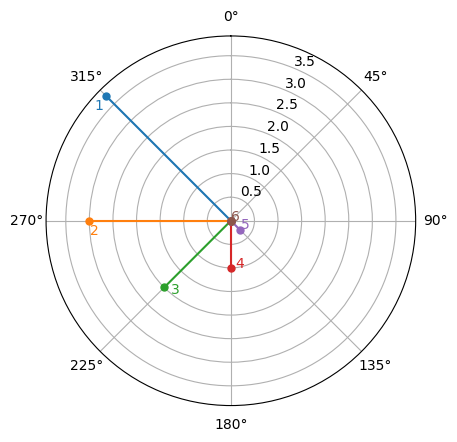

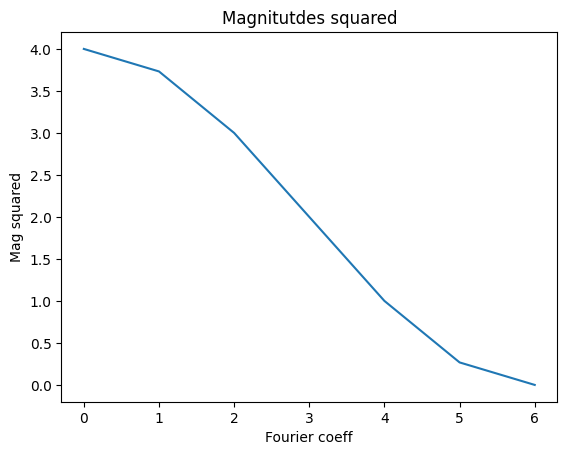

In [3]:
#@title 12EDO pc class dft calculator
import sys # Import sys for sys.exit()
import numpy as np # Import numpy as it's used in this cell

print("Input your pc class (separate with commas, maximum of 12 pitch classes with multisets allowed), or end:")
pc_set=input()
while True:
  pc_set_s=pc_set.split(",")
  pc_set_array=np.array(pc_set_s, dtype=int) # Convert to integer array
  if np.any(pc_set_array > 11):
    print("please keep pitches under 11")
    pc_set=input()
  else:
    break

dft_pcset(input_array=pc_set_array)

Put in a 12 tone row, separated by commas, with 0-11 once each
1,2,3,4,5,6,7,8,9,0,e,t
Partition: hex_one
Characteristic Function: [0 1 1 1 1 1 1 0 0 0 0 0]
Magnitudes squared: [36.   14.93  0.    2.    0.    1.07  0.  ]
Normalized phase: [-3.5  0.  -4.5  0.  -5.5  0. ]
Phase: [-105.    0. -135.    0. -165.    0.]


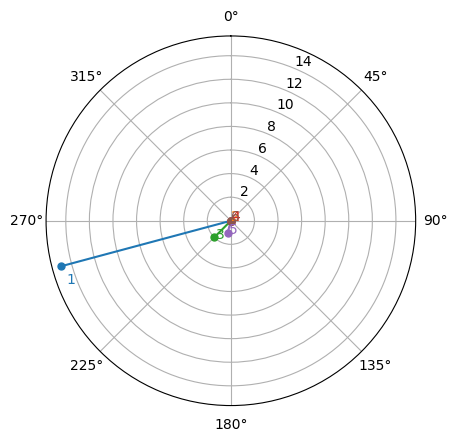

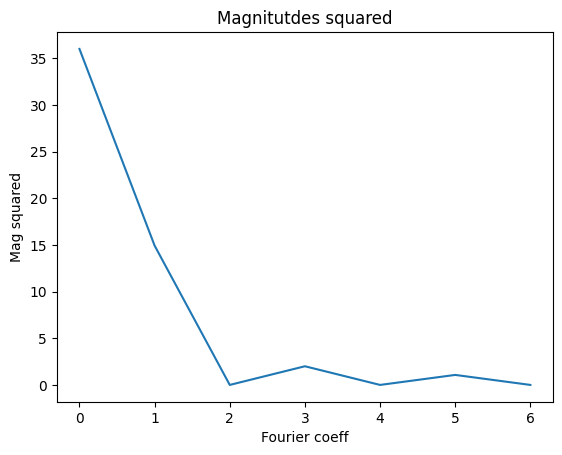

Partition: hex_two
Characteristic Function: [1 0 0 0 0 0 0 1 1 1 1 1]
Magnitudes squared: [36.   14.93  0.    2.    0.    1.07  0.  ]
Normalized phase: [2.5 0.  1.5 0.  0.5 0. ]
Phase: [75.  0. 45.  0. 15.  0.]


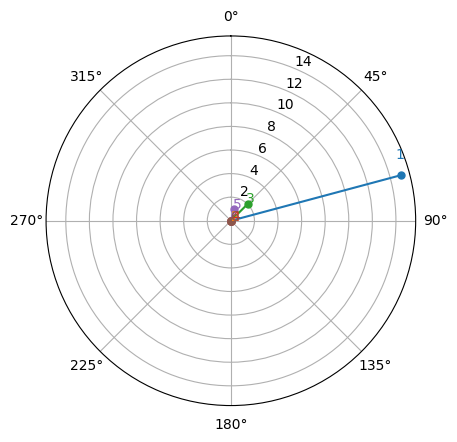

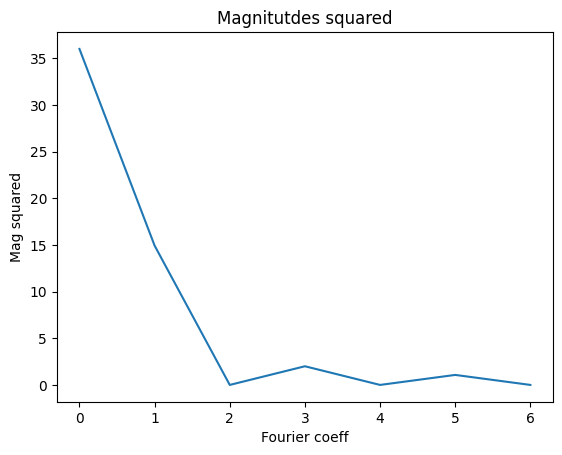

Partition: tetra_one
Characteristic Function: [0 1 1 1 1 0 0 0 0 0 0 0]
Magnitudes squared: [16.  11.2  3.   0.   1.   0.8  0. ]
Normalized phase: [-2.5 -5.   0.  -4.   5.5  6. ]
Phase: [ -75. -150.    0. -120.  165.  180.]


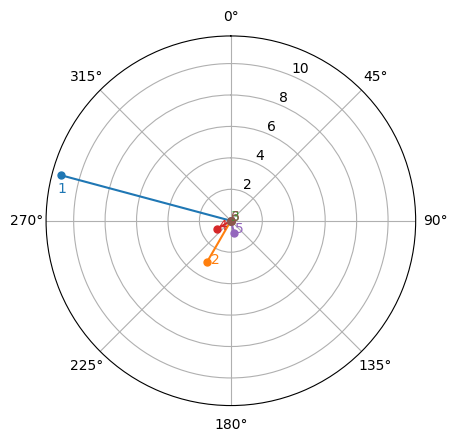

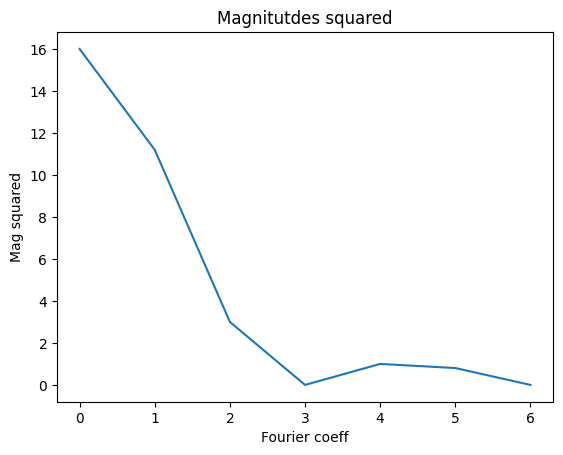

Partition: tetra_two
Characteristic Function: [0 0 0 0 0 1 1 1 1 0 0 0]
Magnitudes squared: [16.  11.2  3.   0.   1.   0.8  0. ]
Normalized phase: [ 5.5 -1.   4.5  4.  -2.5  0. ]
Phase: [165. -30. 135. 120. -75.   0.]


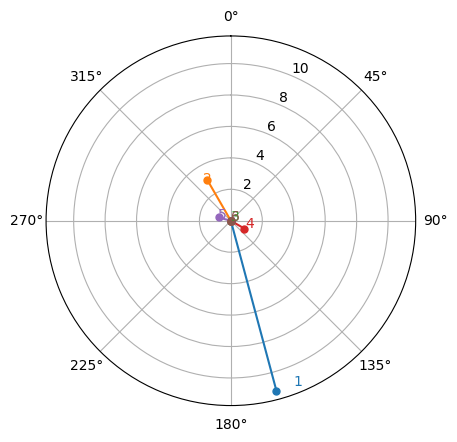

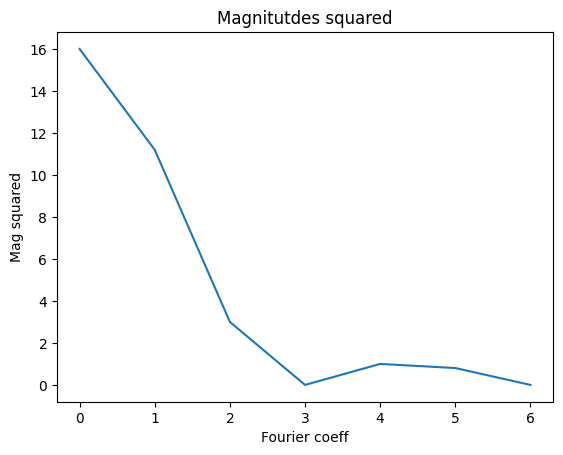

Partition: tetra_three
Characteristic Function: [1 0 0 0 0 0 0 0 0 1 1 1]
Magnitudes squared: [16.  11.2  3.   0.   1.   0.8  0. ]
Normalized phase: [ 1.5  3.  -3.   0.   1.5  0. ]
Phase: [ 45.  90. -90.   0.  45.   0.]


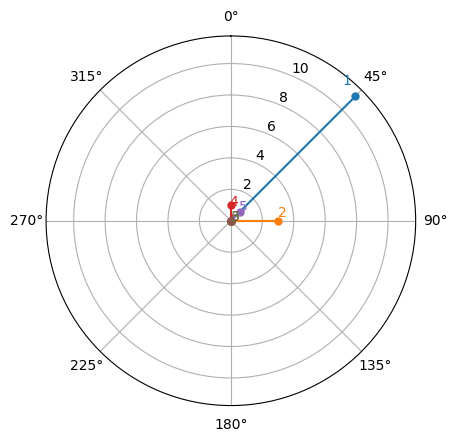

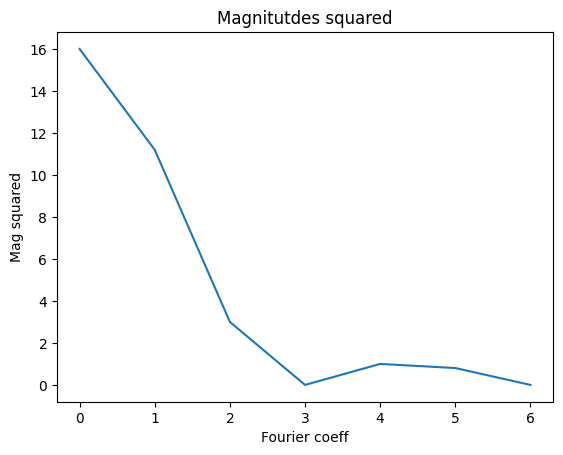

Partition: tri_one
Characteristic Function: [0 1 1 1 0 0 0 0 0 0 0 0]
Magnitudes squared: [9.   7.46 4.   1.   0.   0.54 1.  ]
Normalized phase: [-2. -4.  6.  0. -4.  6.]
Phase: [ -60. -120.  180.    0. -120.  180.]


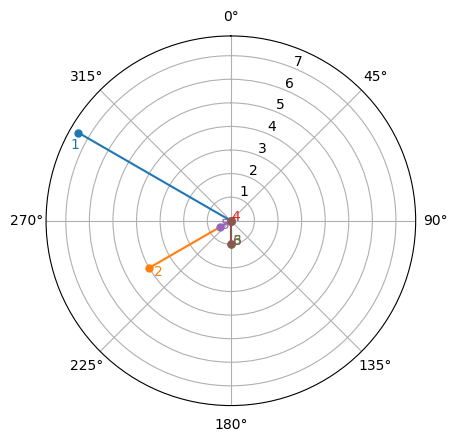

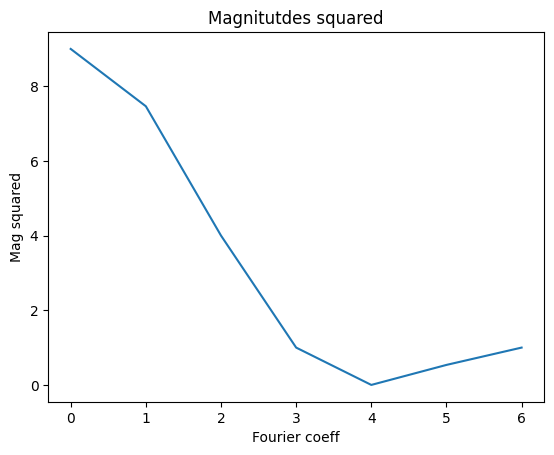

Partition: tri_two
Characteristic Function: [0 0 0 0 1 1 1 0 0 0 0 0]
Magnitudes squared: [9.   7.46 4.   1.   0.   0.54 1.  ]
Normalized phase: [-5.  2. -3.  0.  5.  0.]
Phase: [-150.   60.  -90.    0.  150.    0.]


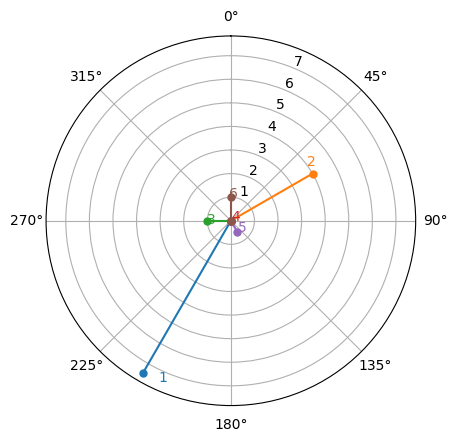

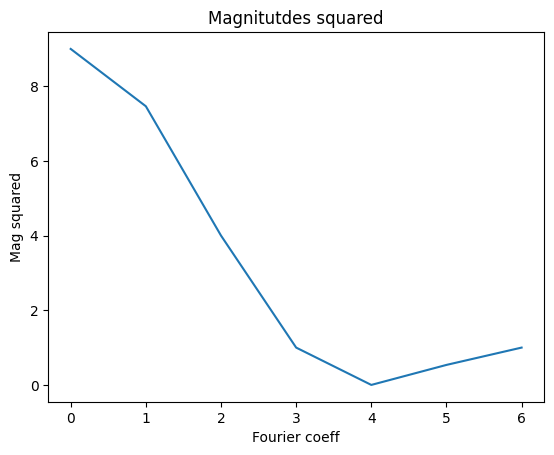

Partition: tri_three
Characteristic Function: [0 0 0 0 0 0 0 1 1 1 0 0]
Magnitudes squared: [9.   7.46 4.   1.   0.   0.54 1.  ]
Normalized phase: [ 4. -4.  0.  0.  2.  6.]
Phase: [ 120. -120.    0.    0.   60.  180.]


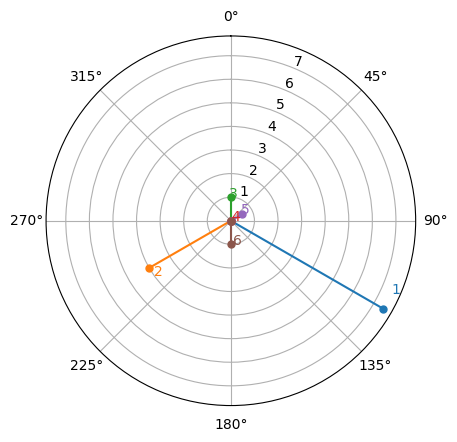

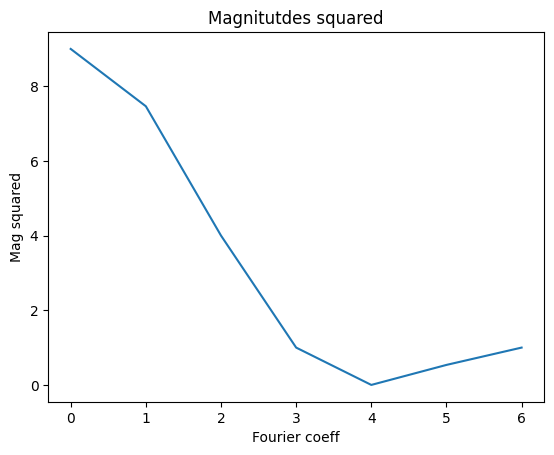

Partition: tri_four
Characteristic Function: [1 0 0 0 0 0 0 0 0 0 1 1]
Magnitudes squared: [9.   7.46 4.   1.   0.   0.54 1.  ]
Normalized phase: [ 1.  2.  3.  0. -1.  0.]
Phase: [ 30.  60.  90.   0. -30.   0.]


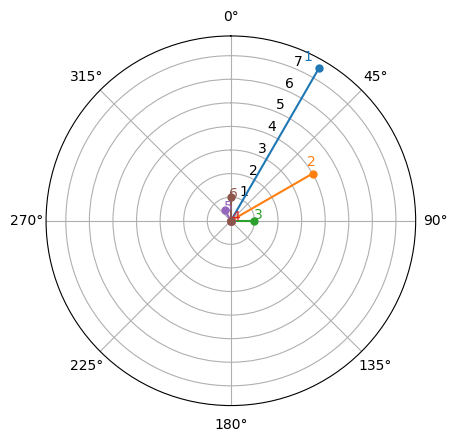

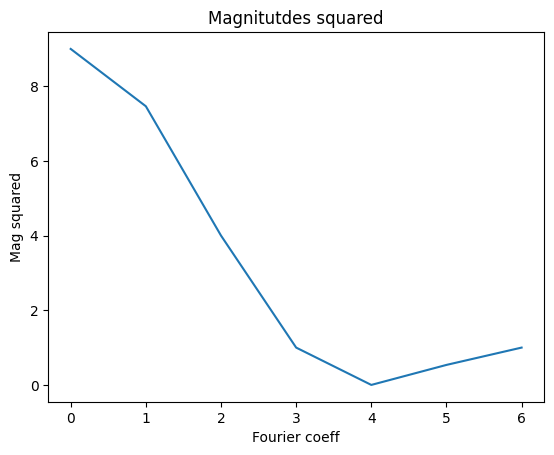

In [4]:
#@title Row properties

import numpy as np

print("Put in a 12 tone row, separated by commas, with 0-11 once each")
row = input()
while True:
  row_s = row.split(",")
  if "t" in row_s:
    row_s[row_s.index("t")] = "10"
  if "e" in row_s:
    row_s[row_s.index("e")] = "11"
  row_array=np.array(row_s, dtype=int) # Convert to integer array
  if np.any(row_array > 11):
    print("please keep pitches under 11")
    row=input()
  elif np.any(row_array < 0):
    print("please keep pitches above 0")
    row=input()
  elif len(row_array) != 12:
    print("Need 12 pitch classes")
    row=input()
  elif len(np.unique(row_array)) != len(row_array):
    print("No duplicates")
    row=input()
  else:
    break

hex_one = row_array[0:6]
hex_two = row_array[6:12]

tetra_one = row_array[0:4]
tetra_two = row_array[4:8]
tetra_three = row_array[8:12]

tri_one = row_array[0:3]
tri_two = row_array[3:6]
tri_three = row_array[6:9]
tri_four = row_array[9:12]

partition_list = {"hex_one": hex_one,
                  "hex_two": hex_two,
                  "tetra_one": tetra_one,
                  "tetra_two": tetra_two,
                  "tetra_three": tetra_three,
                  "tri_one": tri_one,
                  "tri_two": tri_two,
                  "tri_three": tri_three,
                  "tri_four": tri_four}

for name, partition in partition_list.items():
  print("Partition:", name)
  dft_pcset(input_array = partition)